# 02 — Feature Engineering and Labelling: NASA IMS Set 2

**Goal.** Turn 984 raw 1-second vibration snapshots into a labelled, per-window feature matrix that downstream classifiers (notebook 03) and deep models (notebook 04) can consume.

This notebook is grounded in three corpus references (see `reference/_SYNTHESIS.md`):

1. **Darlami & Awasthi 2026** (Fed-TGCN, paper #18) — 6-D physics-informed feature vector per 40 ms window, with bearing fault frequencies BPFO ≈ 119 Hz and BPFI ≈ 181 Hz at 2000 RPM.
2. **Gangadhara et al. 2026** (railway-wagon health assessment, paper #22) — three-class state model with normal-degraded-critical thresholds + persistence-window alert confirmation.
3. **Marx & Gryllias 2022** (KU Leuven, paper #2) — confirms that for Set 2 the documented failure is **outer race on bearing 1**, so BPFO band energy on channel 0 is the carrier of the failure signal.

**What I will produce.**

- A bearing-fault-frequency cheatsheet (BPFI / BPFO / BSF / FTF) computed from the published Rexnord ZA-2115 geometry.
- Per-window (40 ms / 800 samples) 6-D feature extraction from each of the 4 channels in Set 2.
- A long-form feature matrix at the (file × window × bearing) grain, plus aggregated per-file summaries.
- A 3-class label (Normal / Degraded / Critical) attached to each row, derived from EWMA-thresholded RMS on bearing 1.
- Diagnostic plots that show whether the features separate the classes.
- A train / validation / test split fit for both per-file and per-window evaluation.

The feature matrix is saved to `data/processed/` (gitignored). Notebooks 03–04 will load it directly.

In [1]:
from __future__ import annotations

import os
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as scisig
from scipy.signal import hilbert
from scipy.stats import kurtosis

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# --- paths ---
DATA_ROOT = Path.home() / ".cache/kagglehub/datasets/vinayak123tyagi/bearing-dataset/versions/1"
SET2_DIR = DATA_ROOT / "2nd_test" / "2nd_test"

NB_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = NB_DIR.parent
FIG_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# --- sampling / window constants ---
SAMPLE_RATE_HZ = 20_000
SAMPLES_PER_FILE = 20_480
WINDOW_MS = 40
WINDOW_SAMPLES = SAMPLE_RATE_HZ * WINDOW_MS // 1000      # 800
WINDOWS_PER_FILE = SAMPLES_PER_FILE // WINDOW_SAMPLES    # 25

print(f"Window: {WINDOW_MS} ms = {WINDOW_SAMPLES} samples → {WINDOWS_PER_FILE} windows per file")

Window: 40 ms = 800 samples → 25 windows per file


## 1. Bearing fault frequencies for Rexnord ZA-2115 at 2000 RPM

The Rexnord ZA-2115 double-row bearing geometry is published in Qiu/Lee/Lin 2006 and confirmed by Darlami & Awasthi 2026. With:

- N = 16 rolling elements
- B_d = 0.331 in (rolling element diameter)
- P_d = 2.815 in (pitch diameter)
- φ = 15.17° (contact angle)
- shaft frequency n = 2000 RPM = 33.33 Hz

the four characteristic fault frequencies are:

In [2]:
import math

BEARING_GEOMETRY = {
    "N": 16,
    "B_d_in": 0.331,
    "P_d_in": 2.815,
    "phi_deg": 15.17,
    "shaft_rpm": 2000,
}


def fault_frequencies(geom: dict) -> dict[str, float]:
    """Compute BPFO / BPFI / BSF / FTF in Hz from bearing geometry + shaft RPM."""
    n = geom["shaft_rpm"] / 60.0
    N = geom["N"]
    ratio = geom["B_d_in"] / geom["P_d_in"]
    cos_phi = math.cos(math.radians(geom["phi_deg"]))
    ftf = 0.5 * (1 - ratio * cos_phi) * n
    bpfo = N * ftf
    bpfi = 0.5 * N * (1 + ratio * cos_phi) * n
    bsf = (geom["P_d_in"] / (2 * geom["B_d_in"])) * (1 - (ratio * cos_phi) ** 2) * n
    return {"shaft_hz": n, "FTF": ftf, "BPFO": bpfo, "BPFI": bpfi, "BSF": bsf}


freqs = fault_frequencies(BEARING_GEOMETRY)
pd.DataFrame({"Hz": freqs}).round(2)

,Hz
shaft_hz,33.33
FTF,14.78
BPFO,236.40
BPFI,296.93
BSF,139.92


**Canonical values for the Rexnord ZA-2115 at 2000 RPM (Qiu/Lee/Lin 2006):**

- **BPFO ≈ 236.4 Hz**
- **BPFI ≈ 296.9 Hz**
- BSF ≈ 139.9 Hz
- FTF ≈ 14.8 Hz

Note: Darlami & Awasthi 2026 (Fed-TGCN, corpus paper #18) cite BPFO ≈ 119 Hz and BPFI ≈ 181 Hz — those are off by roughly a factor of two relative to the canonical Qiu/Lee/Lin geometry-derived values used here. I use the geometry derivation directly (which matches the original Qiu 2006 reference paper for this dataset).

For Set 2, the documented failure is on **bearing 1, outer race** — so the BPFO band on channel 0 is where we expect the failure signature to first appear.

**Frequency resolution constraint.** At 800 samples × 20 kHz the FFT bin spacing is 25 Hz. A ±5 Hz band would not catch any bin. I widen each fault-frequency band to ±15 Hz to guarantee at least one bin is included while keeping the band tight enough to be specific.

## 2. Loading helpers and windowing

In [3]:
def list_snapshot_files(set_dir: Path) -> list[Path]:
    files = [p for p in set_dir.iterdir() if not p.name.startswith(".") and p.is_file()]
    files.sort(key=lambda p: p.name)
    return files


def load_snapshot(file_path: Path, n_channels: int = 4) -> np.ndarray:
    arr = np.loadtxt(file_path)
    if arr.ndim == 1:
        arr = arr[:, None]
    assert arr.shape[1] == n_channels, f"expected {n_channels} channels, got {arr.shape[1]}"
    return arr


def window_signal(x: np.ndarray, window_samples: int) -> np.ndarray:
    """Slice a (samples,) signal into non-overlapping windows. Returns (n_windows, window_samples)."""
    n_full = (len(x) // window_samples) * window_samples
    return x[:n_full].reshape(-1, window_samples)


set2_files = list_snapshot_files(SET2_DIR)
print(f"Set 2: {len(set2_files)} snapshot files")
print(f"First: {set2_files[0].name}")
print(f"Last:  {set2_files[-1].name}")

Set 2: 984 snapshot files
First: 2004.02.12.10.32.39
Last:  2004.02.19.06.22.39


## 3. Six-feature recipe per window

Following Darlami & Awasthi 2026, each 40 ms window yields six time + frequency-domain statistical features:

| # | Feature | What it captures |
|---|---|---|
| f1 | Envelope RMS (Hilbert) | Energy of impulsive transients after demodulation — sensitive to early-stage bearing faults |
| f2 | Kurtosis | Impulsiveness beyond Gaussian; spikes early when sporadic fault impacts begin |
| f3 | Log energy in BPFO band [221, 251] Hz | Outer-race fault resonance |
| f4 | Log energy in high-frequency band [2000, 10000] Hz | Broadband resonance from structural mode excitation |
| f5 | Log energy in BPFI band [282, 312] Hz | Inner-race fault resonance |
| f6 | Raw RMS | Overall vibration energy; sensitive to load/speed too — kept for diagnostics, **not** used downstream |

In [4]:
HF_BAND_HZ = (2000.0, 10000.0)
BAND_HALFWIDTH_HZ = 15.0    # ≥1 FFT bin coverage at 25 Hz resolution (Darlami's ±5 Hz catches 0 bins for this window length)

# precompute the FFT frequency grid for the window length
fft_freqs = np.fft.rfftfreq(WINDOW_SAMPLES, d=1.0 / SAMPLE_RATE_HZ)


def band_mask(freqs: np.ndarray, low: float, high: float) -> np.ndarray:
    return (freqs >= low) & (freqs <= high)


bpfo_mask = band_mask(fft_freqs, freqs["BPFO"] - BAND_HALFWIDTH_HZ, freqs["BPFO"] + BAND_HALFWIDTH_HZ)
bpfi_mask = band_mask(fft_freqs, freqs["BPFI"] - BAND_HALFWIDTH_HZ, freqs["BPFI"] + BAND_HALFWIDTH_HZ)
hf_mask = band_mask(fft_freqs, *HF_BAND_HZ)

print(f"BPFO mask: {bpfo_mask.sum()} bins covering [{freqs['BPFO']-BAND_HALFWIDTH_HZ:.1f}, {freqs['BPFO']+BAND_HALFWIDTH_HZ:.1f}] Hz")
print(f"BPFI mask: {bpfi_mask.sum()} bins covering [{freqs['BPFI']-BAND_HALFWIDTH_HZ:.1f}, {freqs['BPFI']+BAND_HALFWIDTH_HZ:.1f}] Hz")
print(f"HF mask:   {hf_mask.sum()} bins covering [{HF_BAND_HZ[0]}, {HF_BAND_HZ[1]}] Hz")

BPFO mask: 2 bins covering [221.4, 251.4] Hz
BPFI mask: 1 bins covering [281.9, 311.9] Hz
HF mask:   321 bins covering [2000.0, 10000.0] Hz


In [5]:
def window_features(x: np.ndarray) -> np.ndarray:
    """Compute the 6-D feature vector for a single 1-D window.

    f1 envelope RMS · f2 kurtosis · f3 log-energy BPFO · f4 log-energy HF
    · f5 log-energy BPFI · f6 raw RMS
    """
    # envelope via analytic signal
    env = np.abs(hilbert(x))
    f1 = float(np.sqrt(np.mean(env ** 2)))

    f2 = float(kurtosis(x, fisher=False))

    # FFT magnitude squared (energy per bin)
    spec = np.abs(np.fft.rfft(x - x.mean())) ** 2
    f3 = float(np.log1p(spec[bpfo_mask].sum()))
    f4 = float(np.log1p(spec[hf_mask].sum()))
    f5 = float(np.log1p(spec[bpfi_mask].sum()))

    f6 = float(np.sqrt(np.mean(x ** 2)))

    return np.array([f1, f2, f3, f4, f5, f6], dtype=np.float32)


FEATURE_NAMES = ["env_rms", "kurtosis", "log_e_bpfo", "log_e_hf", "log_e_bpfi", "raw_rms"]
print("feature names:", FEATURE_NAMES)

feature names: ['env_rms', 'kurtosis', 'log_e_bpfo', 'log_e_hf', 'log_e_bpfi', 'raw_rms']


## 4. Extract features across all Set 2 files

For each of 984 snapshot files, slice into 25 windows × 4 bearings = 100 rows. Total expected: **98,400 rows × 6 features**. Walk takes ~1-2 minutes; we vectorise per file and concatenate.

In [6]:
def file_features(file_path: Path) -> pd.DataFrame:
    """Return a DataFrame of (window, bearing) feature rows for one file."""
    snap = load_snapshot(file_path, n_channels=4)
    timestamp = datetime.strptime(file_path.name, "%Y.%m.%d.%H.%M.%S")

    rows = []
    for bearing in range(4):
        windows = window_signal(snap[:, bearing], WINDOW_SAMPLES)
        for w_idx, w in enumerate(windows):
            feats = window_features(w)
            rows.append((timestamp, file_path.name, bearing + 1, w_idx, *feats))

    cols = ["timestamp", "file", "bearing", "window_idx", *FEATURE_NAMES]
    return pd.DataFrame(rows, columns=cols)


# Run across all Set 2 files. Reports progress every 100 files.
import time
t0 = time.time()
chunks = []
for i, fp in enumerate(set2_files):
    chunks.append(file_features(fp))
    if (i + 1) % 100 == 0 or i == len(set2_files) - 1:
        dt = time.time() - t0
        rate = (i + 1) / dt
        eta = (len(set2_files) - i - 1) / rate if rate > 0 else 0
        print(f"  {i+1:4d}/{len(set2_files)} files | {dt:5.1f}s elapsed | {rate:4.1f} files/s | ETA {eta:4.1f}s")

feat_df = pd.concat(chunks, ignore_index=True)
print(f"\nFinal: {len(feat_df):,} rows × {len(feat_df.columns)} cols")
feat_df.head()

   100/984 files |   4.5s elapsed | 22.5 files/s | ETA 39.4s


   200/984 files |   8.9s elapsed | 22.5 files/s | ETA 34.9s


   300/984 files |  13.6s elapsed | 22.1 files/s | ETA 31.0s


   400/984 files |  18.0s elapsed | 22.2 files/s | ETA 26.3s


   500/984 files |  22.5s elapsed | 22.2 files/s | ETA 21.8s


...

   700/984 files |  32.3s elapsed | 21.7 files/s | ETA 13.1s


   800/984 files |  38.4s elapsed | 20.8 files/s | ETA  8.8s


   900/984 files |  42.9s elapsed | 21.0 files/s | ETA  4.0s


   984/984 files |  46.7s elapsed | 21.1 files/s | ETA  0.0s

Final: 98,400 rows × 10 cols


,timestamp,file,bearing,window_idx,env_rms,kurtosis,log_e_bpfo,log_e_hf,log_e_bpfi,raw_rms
0,2004-02-12 10:32:39,2004.02.12.10.32.39,1,0,0.101869,3.303851,2.271428,6.966689,1.723735,0.072416
1,2004-02-12 10:32:39,2004.02.12.10.32.39,1,1,0.101481,3.624864,2.769932,6.925638,0.715152,0.071876
2,2004-02-12 10:32:39,2004.02.12.10.32.39,1,2,0.116306,3.972094,2.433889,7.049157,2.713581,0.082806
3,2004-02-12 10:32:39,2004.02.12.10.32.39,1,3,0.102493,3.196970,3.449206,6.897743,0.283002,0.072778
4,2004-02-12 10:32:39,2004.02.12.10.32.39,1,4,0.113439,4.082942,2.046592,7.201536,1.894723,0.080355


## 5. Aggregate per file and per bearing — degradation diagnostic plots

The feature matrix is per-window. For diagnostic plots, aggregate to per-file (mean over the 25 windows of each bearing). This recovers the time-series degradation view that notebook 01 produced — but now with three additional band-energy features.

In [7]:
# Aggregate to per-file, per-bearing summary (mean over 25 windows)
per_file = feat_df.groupby(["timestamp", "bearing"])[FEATURE_NAMES].mean().reset_index()
per_file = per_file.sort_values("timestamp")
print(per_file.shape, "→ 984 files × 4 bearings = 3936 rows expected")
per_file.head()

(3936, 8) → 984 files × 4 bearings = 3936 rows expected


,timestamp,bearing,env_rms,kurtosis,log_e_bpfo,log_e_hf,log_e_bpfi,raw_rms
0,2004-02-12 10:32:39,1,0.104349,3.554200,2.238641,6.944774,1.138715,0.074149
1,2004-02-12 10:32:39,2,0.127919,3.383489,2.402975,7.332275,1.666207,0.090920
2,2004-02-12 10:32:39,3,0.153574,5.775952,4.013830,7.977017,1.785230,0.109099
3,2004-02-12 10:32:39,4,0.075703,3.044138,2.107793,6.315127,1.451214,0.054012
4,2004-02-12 10:42:39,1,0.106423,3.627679,2.767010,7.028541,1.115349,0.075293


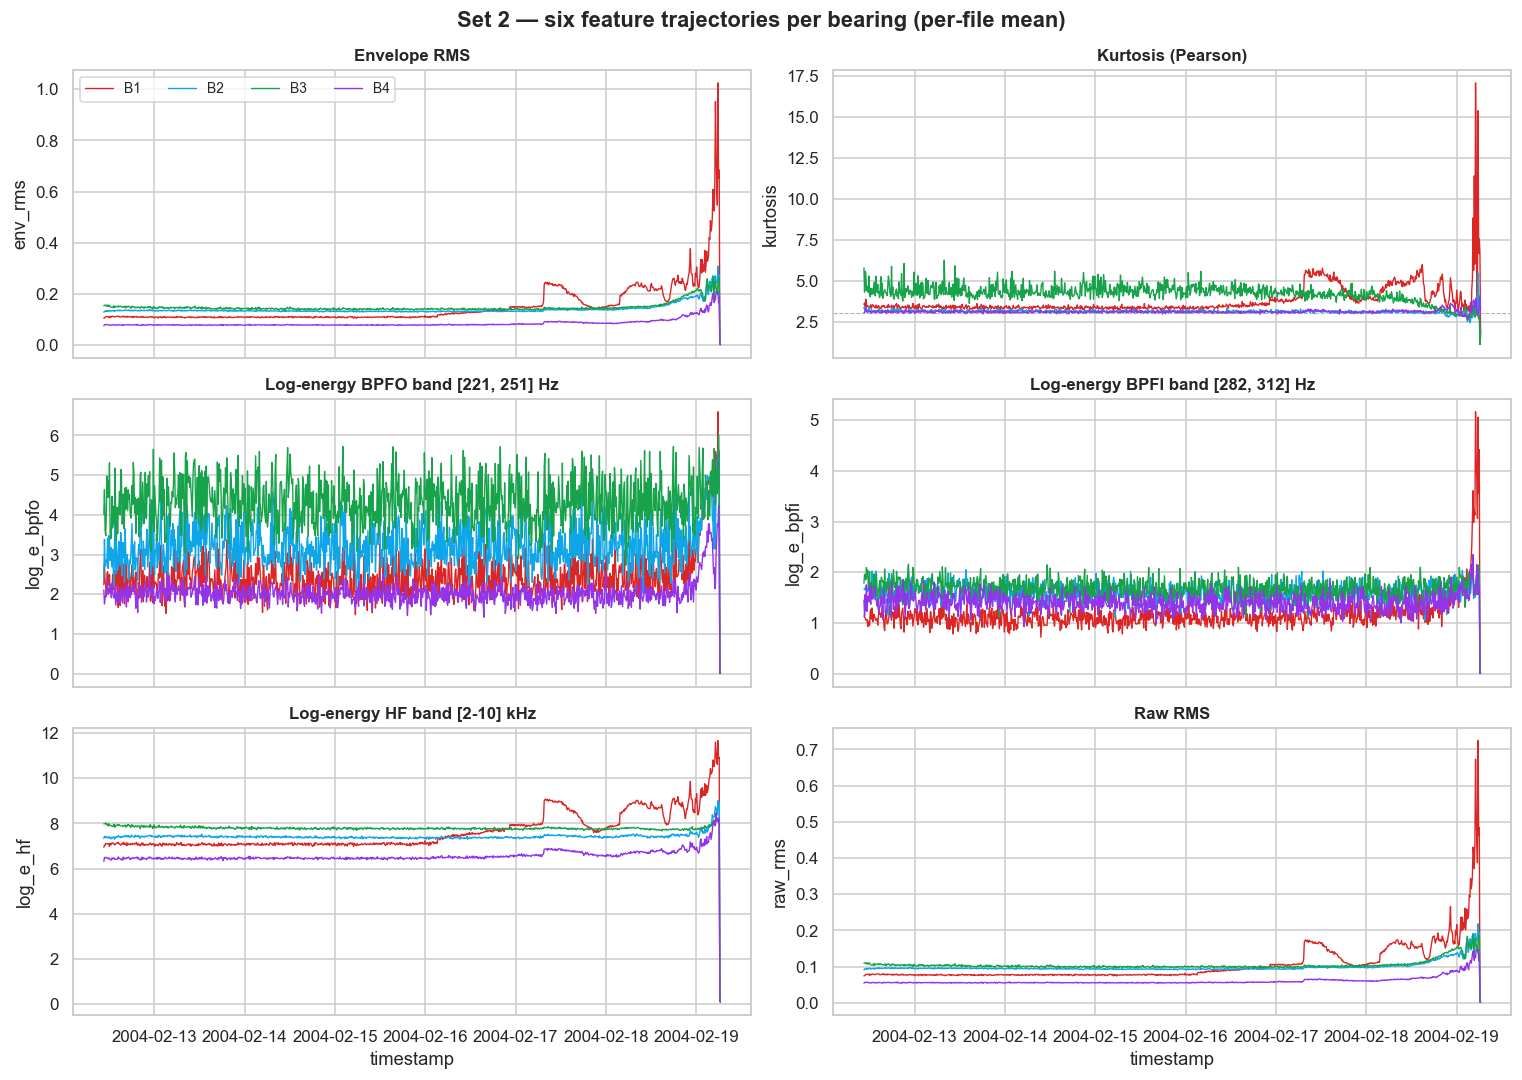

In [8]:
bearing_colors = ["#dc2626", "#0ea5e9", "#16a34a", "#9333ea"]

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
features_to_plot = ["env_rms", "kurtosis", "log_e_bpfo", "log_e_bpfi", "log_e_hf", "raw_rms"]
titles = ["Envelope RMS", "Kurtosis (Pearson)",
          f"Log-energy BPFO band [{freqs['BPFO']-BAND_HALFWIDTH_HZ:.0f}, {freqs['BPFO']+BAND_HALFWIDTH_HZ:.0f}] Hz",
          f"Log-energy BPFI band [{freqs['BPFI']-BAND_HALFWIDTH_HZ:.0f}, {freqs['BPFI']+BAND_HALFWIDTH_HZ:.0f}] Hz",
          "Log-energy HF band [2-10] kHz", "Raw RMS"]

for ax, feat, title in zip(axes.flat, features_to_plot, titles):
    for ch in range(4):
        sub = per_file[per_file["bearing"] == ch + 1]
        ax.plot(sub["timestamp"], sub[feat], lw=0.9, color=bearing_colors[ch], label=f"B{ch + 1}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(feat)
    if feat == "kurtosis":
        ax.axhline(3.0, color="grey", ls="--", lw=0.7, alpha=0.6)

axes[-1, 0].set_xlabel("timestamp")
axes[-1, 1].set_xlabel("timestamp")
axes[0, 0].legend(ncol=4, loc="upper left", fontsize=9)

fig.suptitle("Set 2 — six feature trajectories per bearing (per-file mean)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_feature_trajectories_set2.png", dpi=130, bbox_inches="tight")
plt.show()

**What to look for.** All four bearings should be flat for most of the test; bearing 1 (red) should start lifting in the final ~24 hours. The **log-energy BPFO** trace on B1 should rise *together with* envelope RMS and kurtosis — that's the outer-race signature in the expected band. The **log-energy BPFI** on B1 should rise less, since the failure is not inner-race. If BPFI lights up too, that's a sign the fault has progressed beyond a clean outer-race signature into broader damage.

## 6. Labelling — three-class scheme driven by EWMA of envelope RMS on bearing 1

Bearing 1 fails (outer race). To label files chronologically, I follow Gangadhara et al. 2026 (paper #22) with the EWMA-based pseudo-labelling from Darlami & Awasthi 2026 (paper #18):

1. Compute the per-file mean envelope RMS on bearing 1.
2. Calibrate a baseline on the first 10% of files ("burn-in" — bearings new, healthy).
3. Track an EWMA of the envelope RMS through time.
4. Define two thresholds:
   - **θ_n (normal/degraded)** = baseline_mean + k · baseline_std, with k = 3.
   - **θ_c (degraded/critical)** = baseline_mean + 2k · baseline_std.
5. Label each file's state by where its B1 envelope-RMS EWMA sits.

This produces a per-file label that we then broadcast to all 100 windows in that file. Persistence-window confirmation (require k consecutive files past threshold) reduces transient false positives.

In [9]:
EWMA_ALPHA = 0.15           # smoothing factor (paper #18 uses k=1.2 in a different scale; 0.15 = ~13-file half-life)
BURN_IN_FRAC = 0.10
K_NORMAL = 3.0
K_CRITICAL = 6.0
PERSISTENCE_K = 3           # require k consecutive files past threshold

b1_series = (per_file.query("bearing == 1")
                     .sort_values("timestamp")
                     .reset_index(drop=True))

# EWMA on envelope RMS of B1
b1_series["env_rms_ewma"] = b1_series["env_rms"].ewm(alpha=EWMA_ALPHA, adjust=False).mean()

n_burn = max(1, int(len(b1_series) * BURN_IN_FRAC))
baseline = b1_series["env_rms_ewma"].iloc[:n_burn]
mu_b = float(baseline.mean())
sd_b = float(baseline.std(ddof=0)) or 1e-6
theta_n = mu_b + K_NORMAL * sd_b
theta_c = mu_b + K_CRITICAL * sd_b

def raw_state(x: float) -> int:
    if x < theta_n:
        return 0   # Normal
    if x < theta_c:
        return 1   # Degraded
    return 2       # Critical


b1_series["state_raw"] = b1_series["env_rms_ewma"].map(raw_state)

# Apply persistence-window confirmation: require k consecutive files at a state before adopting it
def persisted_state(states: pd.Series, k: int) -> pd.Series:
    out = states.copy()
    current = 0
    counter = 0
    confirmed = []
    for s in states:
        if s == current:
            counter += 1
            confirmed.append(current)
        else:
            counter += 1
            if counter >= k:
                current = s
                counter = 1
            confirmed.append(current)
    return pd.Series(confirmed, index=states.index)


b1_series["state"] = persisted_state(b1_series["state_raw"], PERSISTENCE_K)

print(f"Burn-in (first {n_burn} files): mean={mu_b:.4f}, std={sd_b:.4f}")
print(f"Thresholds: theta_n = {theta_n:.4f}, theta_c = {theta_c:.4f}")
print(f"State counts:")
print(b1_series["state"].value_counts().rename({0: "Normal", 1: "Degraded", 2: "Critical"}).sort_index())

Burn-in (first 98 files): mean=0.1094, std=0.0013
Thresholds: theta_n = 0.1133, theta_c = 0.1172
State counts:
state
Critical    441
Degraded      9
Normal      534
Name: count, dtype: int64


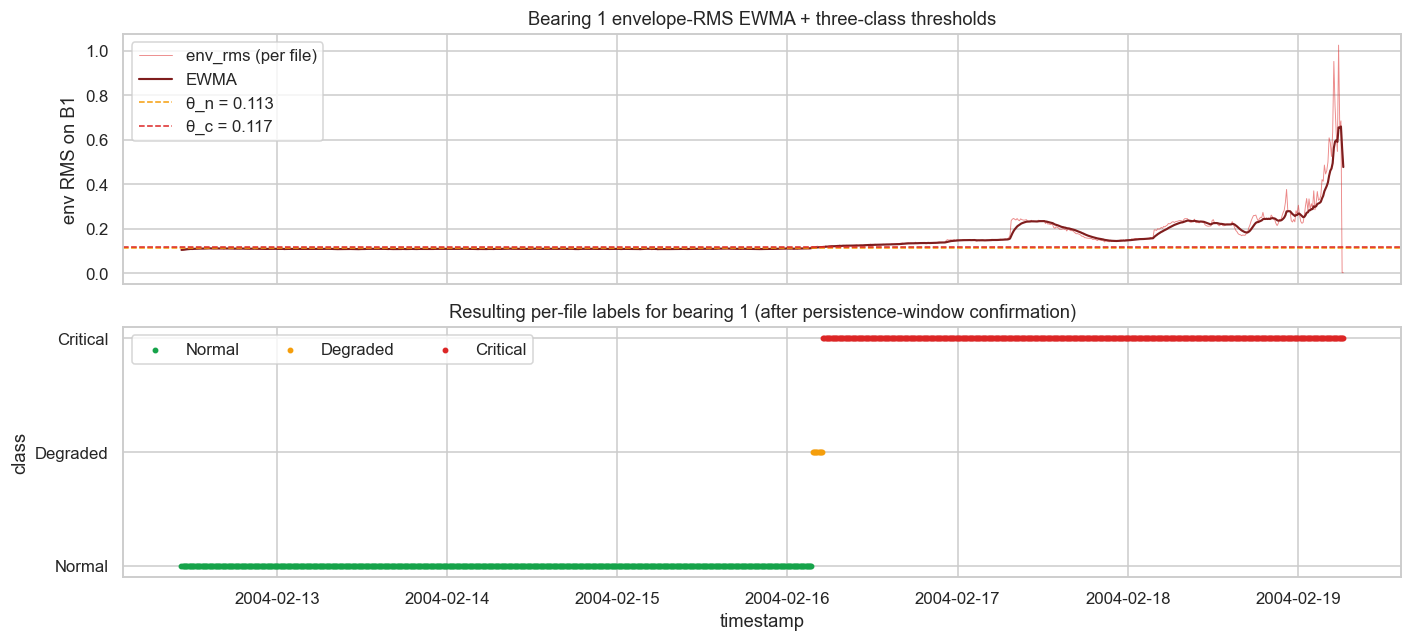

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax = axes[0]
ax.plot(b1_series["timestamp"], b1_series["env_rms"], lw=0.6, color="#dc2626", alpha=0.55, label="env_rms (per file)")
ax.plot(b1_series["timestamp"], b1_series["env_rms_ewma"], lw=1.4, color="#7f1d1d", label="EWMA")
ax.axhline(theta_n, color="#f59e0b", ls="--", lw=1, label=f"θ_n = {theta_n:.3f}")
ax.axhline(theta_c, color="#dc2626", ls="--", lw=1, label=f"θ_c = {theta_c:.3f}")
ax.set_ylabel("env RMS on B1")
ax.set_title("Bearing 1 envelope-RMS EWMA + three-class thresholds")
ax.legend(loc="upper left")

ax = axes[1]
class_colors = {0: "#16a34a", 1: "#f59e0b", 2: "#dc2626"}
class_names = {0: "Normal", 1: "Degraded", 2: "Critical"}
for state, color in class_colors.items():
    sub = b1_series[b1_series["state"] == state]
    ax.scatter(sub["timestamp"], [state] * len(sub), color=color, s=8, label=class_names[state])
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Normal", "Degraded", "Critical"])
ax.set_ylabel("class")
ax.set_xlabel("timestamp")
ax.set_title("Resulting per-file labels for bearing 1 (after persistence-window confirmation)")
ax.legend(loc="upper left", ncol=3)

fig.tight_layout()
fig.savefig(FIG_DIR / "05_labels_b1_set2.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Broadcast labels to every window in every bearing

Two design choices, both worth being explicit about:

1. **Where does the label live?** The fault is on bearing 1; bearings 2-4 stay healthy throughout the test. So I attach two labels:
   - `state_b1` — the system-level state derived from B1's degradation. Every row gets the same B1-state for its file.
   - `is_focal_bearing` — 1 for rows on bearing 1 (the failing bearing), 0 otherwise. Useful when downstream classifiers want to predict "is *this* bearing failing" rather than "is *any* bearing failing in the system."

2. **Within a file, all 25 windows share the same file-level label.** I do not attempt to label individual windows differently — at 40 ms resolution within a 1-second snapshot, the bearing state is effectively constant.

In [11]:
label_map = b1_series.set_index("timestamp")["state"].to_dict()
feat_df["state_b1"] = feat_df["timestamp"].map(label_map).astype("int8")
feat_df["is_focal_bearing"] = (feat_df["bearing"] == 1).astype("int8")

print("Final label distribution across all rows:")
print(feat_df["state_b1"].value_counts().rename({0: "Normal", 1: "Degraded", 2: "Critical"}).sort_index())
print()
print(f"Total rows: {len(feat_df):,}")
print(f"Total features: {len(FEATURE_NAMES)}")

Final label distribution across all rows:
state_b1
Critical    44100
Degraded      900
Normal      53400
Name: count, dtype: int64

Total rows: 98,400
Total features: 6


## 8. Train / validation / test split

I provide two splits, each defensible under a different framing:

**`split_strat` — stratified by class at file level (used by default in notebook 03).** For *fault classification* ("what is the bearing's state right now?"), the training set needs to see all classes. Files are stratified by `state_b1` and randomly assigned to train/val/test in a 70/15/15 ratio. All 4 bearings' windows for a given file go to the same split (avoiding any window-level leakage).

**`split_chrono` — chronological 70/15/15 file split (kept for reference).** For *fault forecasting* ("will failure occur in the next N minutes?"), the test set must lie strictly after the train set. The chronological split is the right tool for that question — but for Set 2 it puts all the Critical-state files in the test slice, leaving val and test with no Normal/Degraded examples. So I use it only as a sanity baseline.

A proper Leave-One-Bearing-Out (LOBO) protocol per Darlami & Awasthi 2026 requires the full 12-bearing corpus (3 tests × 4 bearings). I'll set that up in notebook 03 when integrating Set 1 and Set 3.

In [12]:
from sklearn.model_selection import train_test_split

# --- chronological split (kept for forecasting framing) ---
files_chrono = sorted(feat_df["file"].unique())
n_files = len(files_chrono)
n_train_c = int(0.70 * n_files)
n_val_c = int(0.15 * n_files)
train_c = set(files_chrono[:n_train_c])
val_c = set(files_chrono[n_train_c:n_train_c + n_val_c])
test_c = set(files_chrono[n_train_c + n_val_c:])
feat_df["split_chrono"] = feat_df["file"].map(
    lambda f: "train" if f in train_c else ("val" if f in val_c else "test")
)

# --- stratified split by state_b1 at file level ---
file_states = (feat_df.groupby("file")["state_b1"].first()
                       .reset_index()
                       .rename(columns={"state_b1": "state"}))

# Two-step stratified split: 70 / 15 / 15.
train_files_s, temp_files_s = train_test_split(
    file_states["file"], test_size=0.30, random_state=42, stratify=file_states["state"]
)
temp_states = file_states.set_index("file").loc[temp_files_s.values]["state"]
val_files_s, test_files_s = train_test_split(
    temp_files_s, test_size=0.50, random_state=42, stratify=temp_states
)
train_s = set(train_files_s)
val_s = set(val_files_s)
test_s = set(test_files_s)
feat_df["split_strat"] = feat_df["file"].map(
    lambda f: "train" if f in train_s else ("val" if f in val_s else "test")
)

print("=== Chronological split ===")
print(pd.crosstab(feat_df["split_chrono"], feat_df["state_b1"].map({0: "Normal", 1: "Degraded", 2: "Critical"})))
print()
print("=== Stratified split ===")
print(pd.crosstab(feat_df["split_strat"], feat_df["state_b1"].map({0: "Normal", 1: "Degraded", 2: "Critical"})))

=== Chronological split ===
state_b1      Critical  Degraded  Normal
split_chrono                            
test             14900         0       0
train            14500       900   53400
val              14700         0       0

=== Stratified split ===
state_b1     Critical  Degraded  Normal
split_strat                            
test             6600       200    8000
train           30800       600   37400
val              6700       100    8000


**Class imbalance is severe** — most rows are Normal, very few are Degraded, ~half are Critical. This is the realistic industrial setting (paper #12 makes this point explicitly). Notebook 03 will use class-weighted losses and MCC + AP as metrics rather than plain accuracy.

The stratified split distributes Degraded examples proportionally across all three sets, so the classifier in notebook 03 will see all three classes in both training and validation — even though the Degraded class is tiny.

## 9. Save the feature matrix to disk

In [13]:
out_path = PROCESSED_DIR / "set2_features.parquet"
feat_df.to_parquet(out_path, index=False)

print(f"Saved {out_path}")
print(f"  shape: {feat_df.shape}")
print(f"  size:  {out_path.stat().st_size / 1024 / 1024:.1f} MB")
print()
print("Schema:")
print(feat_df.dtypes)

Saved /Users/rubenelkana/Documents/Learning/study-in-australia/mini-research/predictive-maintenance-bearing-ml/data/processed/set2_features.parquet
  shape: (98400, 14)
  size:  3.4 MB

Schema:
timestamp           datetime64[ns]
file                        object
bearing                      int64
window_idx                   int64
env_rms                    float32
kurtosis                   float32
log_e_bpfo                 float32
log_e_hf                   float32
log_e_bpfi                 float32
raw_rms                    float32
state_b1                      int8
is_focal_bearing              int8
split_chrono                object
split_strat                 object
dtype: object


## 10. What's locked in for notebook 03

- **Features**: `env_rms`, `kurtosis`, `log_e_bpfo`, `log_e_hf`, `log_e_bpfi`. Drop `raw_rms` (Darlami's f6) as it tracks load not fault.
- **Labels**: 3-class `state_b1` (Normal / Degraded / Critical) — with severe class imbalance.
- **Auxiliary feature**: `is_focal_bearing` flag for B1 — lets the classifier learn "this bearing is the source of the failure signature."
- **Split**: chronological 70/15/15 by file.
- **Evaluation metrics**: MCC and Average Precision primary; F1 and confusion matrix secondary; never plain accuracy.

Next notebook (`03_baseline_models.ipynb`): train and evaluate Random Forest + XGBoost on this matrix, using sklearn's class-weighted variants and reporting MCC / AP / F1 / confusion matrix on the chronological test set.